In [1]:
import importlib
import sys
import os

sys.path.append(os.path.abspath("../"))

from utils.gref_pipeline import georef
from gref_pipeline import config

importlib.reload(georef)  # 🔥 Reload to get latest changes
from utils.gref_pipeline.georef import *

print("✅ Module reloaded successfully!")

✅ Module reloaded successfully!


In [2]:
# Check which georef.py is being used
import inspect
from utils.gref_pipeline import georef

# Get the file path of the georef module
georef_file = inspect.getfile(georef)
print(f"📁 Georef module location: {georef_file}")

# Check if it has the _post_classification_filtering method
if hasattr(georef.CombinedTransectCube, "_post_classification_filtering"):
    method = getattr(georef.CombinedTransectCube, "_post_classification_filtering")
    method_file = inspect.getfile(method)
    print(f"📁 _post_classification_filtering method location: {method_file}")

    # Get the source code and check for our debug string
    source = inspect.getsource(method)
    if "ERIK_DEBUG" in source:
        print("✅ Debug code IS in the loaded module!")
    else:
        print("❌ Debug code NOT in the loaded module!")
        print("First 1000 chars of filtering code:")
        print(source[7000:8000])  # Print section where our code should be

📁 Georef module location: c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\gref4hsi\final_act\utils\gref_pipeline\georef.py
📁 _post_classification_filtering method location: c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\gref4hsi\final_act\utils\gref_pipeline\georef.py
✅ Debug code IS in the loaded module!


In [3]:
transect = load_transect(config.OUTPUT_FOLDER)
transect.list_files()

cube = transect.select_files(
    [
        # "rad_uhi_20241029_115057_1",
        # "rad_uhi_20241029_115057_2",
        # "rad_uhi_20241029_115057_3",
        # "rad_uhi_20241029_115057_4",
        "rad_uhi_20241029_115057_5",
        # "rad_uhi_20241029_115057_6",
    ]
)
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462,

In [4]:
cube.apply_illumination_correction_v2()

🔄 Using V2 algorithm (pandas rolling median)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[2.2304249e+00, 1.6764377e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.0077596e+00, 0.0000000e+00],
        [7.4757171e+00, 8.5974735e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.0958059e+00, 0.0000000e+00],
        [1.8294926e+00, 2.3438740e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.1090145e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.4317783e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.7040919e-01],
        [5.8812752e+00, 2.0123754e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.4956644e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.5736811e+01, 4.5105180e-01]],

       [[2.2304249e+00, 7.7452070e-01, 3.9940205e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.7471981e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 8.5029960e-01, 6.3767982e-01],
        [1.9216584e+00, 0.0000000e+00, 3.0771544e+00, ...,
         0.000

In [5]:
cube.import_rois("./ROIs/057_5_combined.json")
cube.list_rois()

📂 Imported 6 ROIs from ./ROIs/057_5_combined.json

📂 ROI Collection (6 ROIs):
 1. 'dark spots': 358 pixels
     Slit range:  174 - 740
     Track range: 729 - 1416
 2. 'all bombs': 454 pixels
     Slit range:  244 - 880
     Track range: 593 - 1547
 3. 'sediment': 273 pixels
     Slit range:   14 - 870
     Track range: 577 - 1580
 4. 'training_dark': 364 pixels
     Slit range:   24 - 962
     Track range:  23 - 2420
 5. 'training_sediment': 398 pixels
     Slit range:   31 - 924
     Track range:  51 - 2417
 6. 'training_bombs': 201 pixels
     Slit range:  513 - 794
     Track range: 2136 - 2416


In [ ]:
training_rois = [
    "training_dark",
    "training_sediment",
    "training_bombs",
]

validation_rois = [
    "validation_dark",
    "validation_sediment",
    "validation_bombs",
]

💡 Interactive mode: Click on the plot to display coordinates


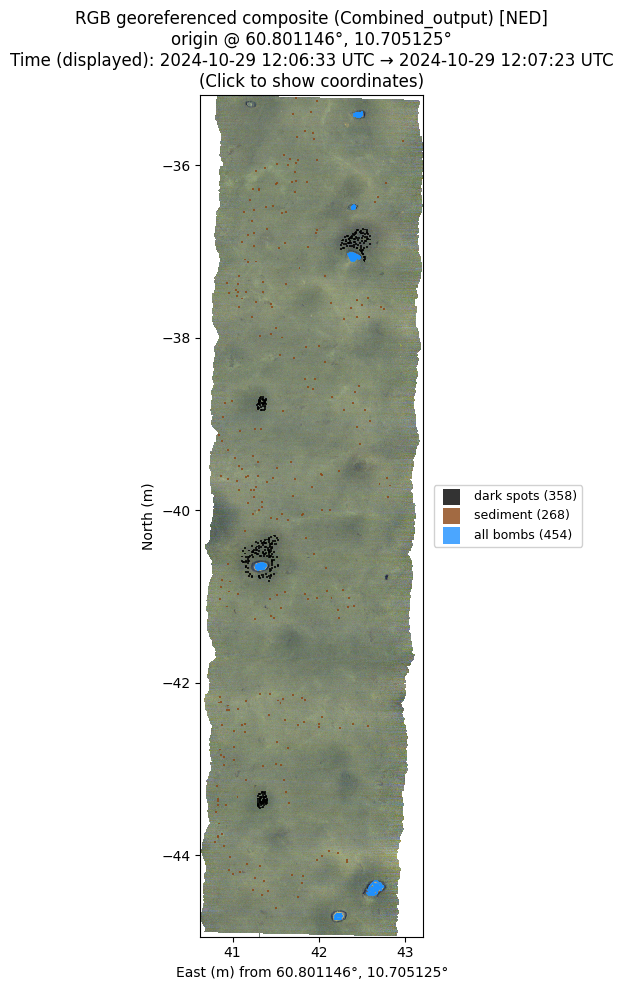

In [7]:
cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(30, 10),
    roi_collection=validation_rois,
    roi_marker_size=2,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

## Train SVM with Custom Class Weights + Brightness Feature

**New features:**
- **Custom class weights**: 2x weight for bombs (improves recall)
- **Brightness feature**: Mean intensity of 490-680nm spectrum
- **Spatial clustering**: Leave-One-Bomb-Out cross-validation

In [8]:
# Define custom class weights (give bombs 2x importance)
custom_weights = {
    # "training_bombs": 2.0,  # 2x weight for bombs (catch more bombs!)
    "training_bombs": 1.2,  # 2x weight for bombs (catch more bombs!)
    "training_dark": 1.0,
    "training_sediment": 1.0,
}

# Train SVM with custom weights + brightness feature
cv_results = cube.train_svm_with_cv(
    training_rois=training_rois,
    segment_start=config.UHI_TRACK_RANGE_5[0],
    segment_end=config.UHI_TRACK_RANGE_5[1],
    wavelength_range=(490, 680),  # ✅ Only use 490-680nm wavelengths
    cv_folds=5,  # Will auto-adjust to number of bomb groups
    use_corrected=True,
    svm_kernel="rbf",
    optimize_params=True,
    # class_weight_dict=custom_weights,  # 🔥 Custom weights (2x for bombs)
    add_brightness_feature=False,  # 🔥 Add brightness (mean intensity)
    quiet=False,
)

# Print summary
print(f"\n" + "=" * 60)
print(f"📊 CROSS-VALIDATION SUMMARY")
print(f"=" * 60)
print(
    f"Accuracy:  {cv_results['cv_mean_metrics']['accuracy_mean']:.3f} ± {cv_results['cv_mean_metrics']['accuracy_std']:.3f}"
)
print(
    f"Precision: {cv_results['cv_mean_metrics']['precision_mean']:.3f} ± {cv_results['cv_mean_metrics']['precision_std']:.3f}"
)
print(
    f"Recall:    {cv_results['cv_mean_metrics']['recall_mean']:.3f} ± {cv_results['cv_mean_metrics']['recall_std']:.3f}"
)
print(
    f"F1 Score:  {cv_results['cv_mean_metrics']['f1_mean']:.3f} ± {cv_results['cv_mean_metrics']['f1_std']:.3f}"
)

print(f"\n🎯 Best hyperparameters:")
print(f"  C = {cv_results['best_params']['C']}")
print(f"  gamma = {cv_results['best_params']['gamma']}")

print(f"\n📍 Training pixels used:")
for class_name, count in cv_results["training_pixels_per_class"].items():
    print(f"  {class_name}: {count} pixels")

🤖 SVM TRAINING WITH CROSS-VALIDATION

� Wavelength filtering:
   Range: 490 - 680 nm
   Wavelengths used: 108 (from 210)

�📦 Datacube shape: (2462, 968, 108)
📏 Using data: corrected
🎯 Segment range: tracks 576 to 1566
📍 Training ROIs: ['training_dark', 'training_sediment', 'training_bombs']

🔍 Filtering ROI pixels...
   training_dark: 364 pixels (rejected 0 inside segment)
   training_sediment: 397 pixels (rejected 1 inside segment)
   training_bombs: 201 pixels (rejected 0 inside segment)

✅ Training data: 962 pixels, 108 features
   Features: 108 wavelengths
   Kept (outside segment): 962
   Rejected (inside segment): 1

🔬 Creating spatial groups for CV...
   Settings: closing_radius=3, min_group_size=20
   Sediment grid: 100(slit) × 200(track) px, min=10
   training_dark: 364 pixels → 6 groups via connected_components
      dark#A: 119 pixels
      dark#B: 50 pixels
      dark#C: 37 pixels
      dark#D: 29 pixels
      dark#E: 51 pixels
      dark#F: 78 pixels
      Merged small til

💡 Interactive mode: Click on the plot to display coordinates


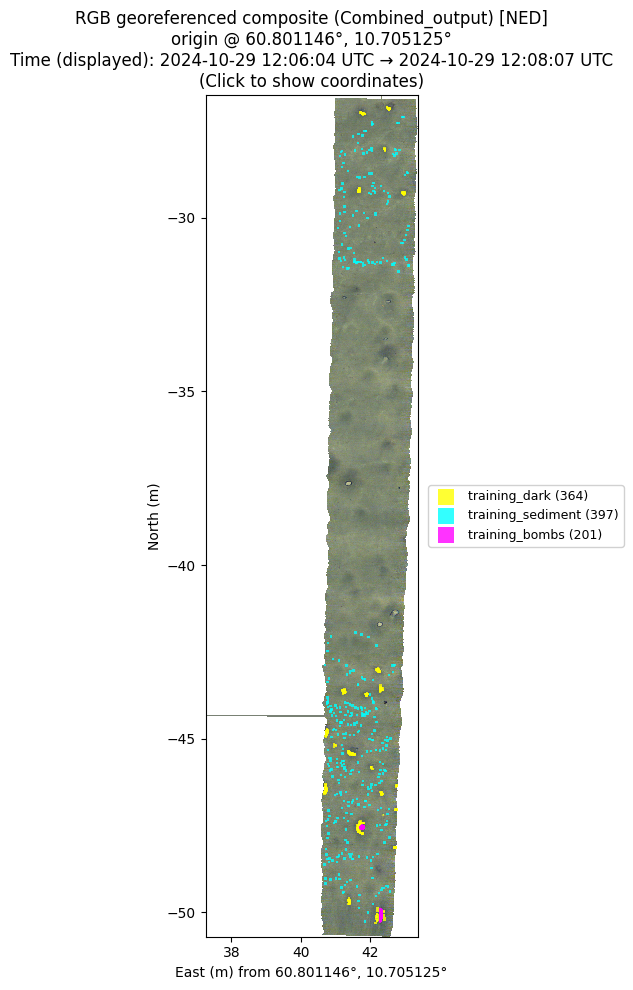

In [9]:
# Visualize FILTERED training ROIs (shows exactly what was used)
%matplotlib inline

cube.plot_georef(
    use_corrected=True,
    figsize=(40, 10),
    roi_collection=cv_results['filtered_training_rois'],
    roi_marker_size=3,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=40,
)

## Visualize Spatial Groups

This shows how the training ROIs were spatially clustered into groups for cross-validation:
- **Bombs**: bomb#1, bomb#2, etc. (connected components)
- **Dark spots**: dark#A, dark#B, etc. (connected components)  
- **Sediment**: sediment_grid_tile_X (grid-based tiles)

💡 Interactive mode: Click on the plot to display coordinates


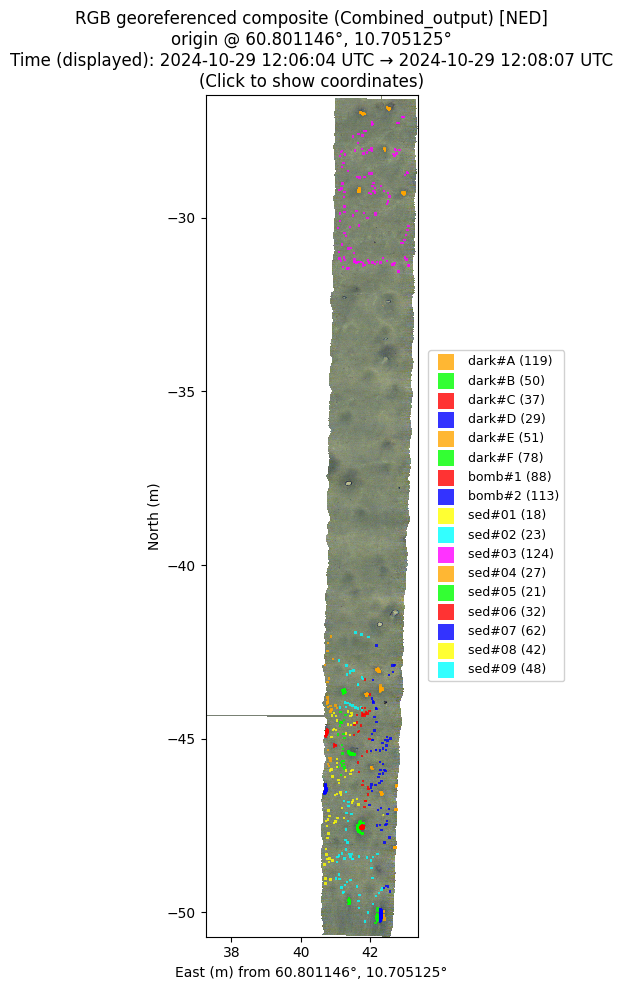


📊 Spatial Groups Created:
   bomb#1: 88 pixels
   bomb#2: 113 pixels
   dark#A: 119 pixels
   dark#B: 50 pixels
   dark#C: 37 pixels
   dark#D: 29 pixels
   dark#E: 51 pixels
   dark#F: 78 pixels
   sed#01: 18 pixels
   sed#02: 23 pixels
   sed#03: 124 pixels
   sed#04: 27 pixels
   sed#05: 21 pixels
   sed#06: 32 pixels
   sed#07: 62 pixels
   sed#08: 42 pixels
   sed#09: 48 pixels


In [10]:
# Plot spatial groups created during training
if (
    "spatial_groups_roi_collection" in cv_results
    and cv_results["spatial_groups_roi_collection"]
):
    cube.plot_georef(
        use_corrected=True,
        figsize=(40, 10),
        roi_collection=cv_results["spatial_groups_roi_collection"],
        roi_marker_size=3,
        roi_legend_loc="outside",
        roi_marker_edgewidth=0,
        roi_legend_markersize=40,
    )

    # Print group info
    print("\n📊 Spatial Groups Created:")
    for group_name, pixels in sorted(
        cv_results["spatial_groups_roi_collection"].items()
    ):
        print(f"   {group_name}: {len(pixels)} pixels")
else:
    print(
        "⚠️ No spatial groups found in cv_results. Training may not have used spatial clustering."
    )

## Classify Segment and Validate

In [11]:
# ============================================================================
# STEP 1: CLASSIFY SEGMENT (pure classification, no filtering)
# ============================================================================
print("🎯 STEP 1: Classifying segment...")
classification_results = cube.classify_segment(
    segment_start=config.UHI_TRACK_RANGE_5[0],
    segment_end=config.UHI_TRACK_RANGE_5[1],
    use_corrected=True,
    quiet=False,
)

print(f"\n✅ Classification complete!")
print(f"   Classes found: {classification_results['class_names']}")
print(f"   Map shape: {classification_results['segment_shape']}")

🎯 STEP 1: Classifying segment...
🎯 SEGMENT CLASSIFICATION (no filtering, no validation)
🎯 SEGMENT CLASSIFICATION WITH VALIDATION

📊 Using wavelength subset: 108 wavelengths

📦 Datacube shape: (2462, 968, 108)
📏 Using data: corrected
🎯 Segment range: tracks 576 to 1566

🔪 Extracting segment...
   Segment shape: (991, 968, 108)

🤖 Classifying 959288 pixels...

📊 Using wavelength subset: 108 wavelengths

📦 Datacube shape: (2462, 968, 108)
📏 Using data: corrected
🎯 Segment range: tracks 576 to 1566

🔪 Extracting segment...
   Segment shape: (991, 968, 108)

🤖 Classifying 959288 pixels...


   Classifying: 100%|█████████████████████████████████| 959288/959288 [13:31<00:00, 1181.98pixels/s]



   ✅ Classification complete in 811.63 seconds

📊 Classification distribution (before filtering):
   training_bombs: 1507 pixels (0.2%)
   training_dark: 86474 pixels (9.0%)
   training_sediment: 871307 pixels (90.8%)

✅ Classification and validation complete!

✅ Classification complete!
   Classes found: ['training_bombs', 'training_dark', 'training_sediment']
   Map shape: (991, 968)

📊 Classification distribution (before filtering):
   training_bombs: 1507 pixels (0.2%)
   training_dark: 86474 pixels (9.0%)
   training_sediment: 871307 pixels (90.8%)

✅ Classification and validation complete!

✅ Classification complete!
   Classes found: ['training_bombs', 'training_dark', 'training_sediment']
   Map shape: (991, 968)


In [12]:
# ============================================================================
# STEP 1B: VALIDATE UNFILTERED CLASSIFICATION (before filtering)
# ============================================================================
print("📊 Validating UNFILTERED classification (before filtering)...")
validation_results_unfiltered = cube.validate_classification(
    classification_map=classification_results["classification_map"],
    segment_start=config.UHI_TRACK_RANGE_5[0],
    segment_end=config.UHI_TRACK_RANGE_5[1],
    validation_rois=validation_rois,
    validation_class_mapping={
        "sediment": "training_sediment",
        "dark spots": "training_dark",
        "all bombs": "training_bombs",
    },
    quiet=False,
)

# Print unfiltered summary
if validation_results_unfiltered:
    print(f"\n" + "=" * 60)
    print(f"📊 UNFILTERED CLASSIFICATION RESULTS")
    print(f"=" * 60)
    print(f"Overall Accuracy: {validation_results_unfiltered['accuracy']:.3f}")

    print(f"\n📋 Per-Class Results (BEFORE filtering):")
    for class_name in classification_results["class_names"]:
        print(f"\n{class_name}:")
        print(
            f"  Precision: {validation_results_unfiltered['precision_per_class'][class_name]:.3f}"
        )
        print(
            f"  Recall:    {validation_results_unfiltered['recall_per_class'][class_name]:.3f}"
        )
        print(
            f"  F1 Score:  {validation_results_unfiltered['f1_per_class'][class_name]:.3f}"
        )
        print(
            f"  Support:   {validation_results_unfiltered['support_per_class'][class_name]} pixels"
        )

📊 Validating UNFILTERED classification (before filtering)...
📊 CLASSIFICATION VALIDATION

📈 Validation Results:
   Overall Accuracy: 0.773

   Per-Class Metrics:
   training_bombs: P=1.000, R=0.469, F1=0.639, Support=454
   training_dark: P=0.967, R=0.989, F1=0.978, Support=358
   training_sediment: P=0.535, R=1.000, F1=0.697, Support=268

📊 UNFILTERED CLASSIFICATION RESULTS
Overall Accuracy: 0.773

📋 Per-Class Results (BEFORE filtering):

training_bombs:
  Precision: 1.000
  Recall:    0.469
  F1 Score:  0.639
  Support:   454 pixels

training_dark:
  Precision: 0.967
  Recall:    0.989
  F1 Score:  0.978
  Support:   358 pixels

training_sediment:
  Precision: 0.535
  Recall:    1.000
  F1 Score:  0.697
  Support:   268 pixels


🔍 About to plot UNFILTERED:
  training_bombs: 1507 pixels


c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\gref4hsi\final_act\utils\gref_pipeline\georef.py:8284: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


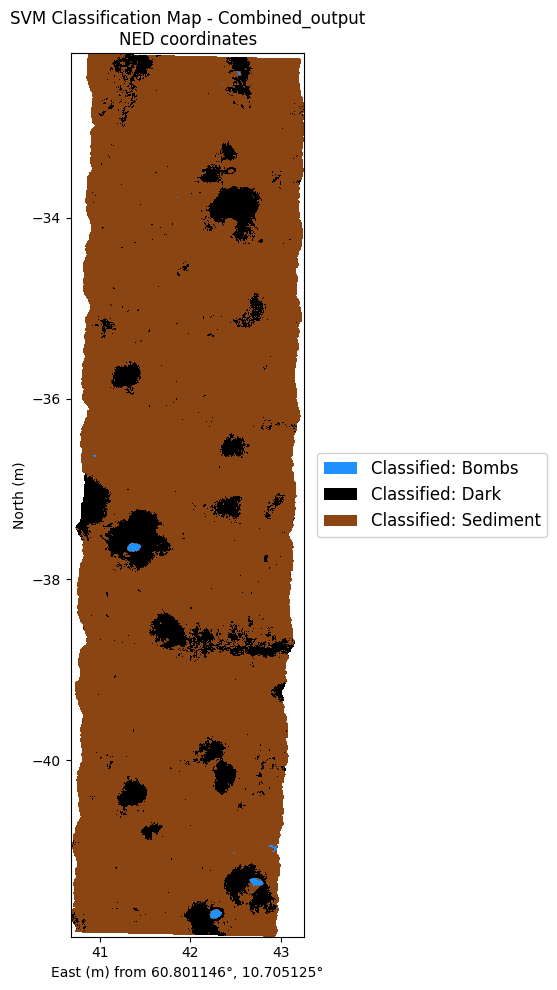

In [13]:
# Plot UNFILTERED classification map (uses VALIDATION ROI colors)
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Set validation class mapping so plot uses correct colors
cube.svm_validation_class_mapping = {
    "sediment": "training_sediment",
    "dark spots": "training_dark",
    "all bombs": "training_bombs",
}

# Get unfiltered map and encode it
unfiltered_map = classification_results["classification_map"]
class_names = classification_results["class_names"]

# Encode the string labels to integers
encoder = LabelEncoder()
encoder.fit(class_names)
unfiltered_map_encoded = encoder.transform(unfiltered_map.flatten()).reshape(
    unfiltered_map.shape
)

# Update cube with unfiltered results
cube.svm_classification_map = unfiltered_map
cube.svm_classification_map_encoded = unfiltered_map_encoded
cube.svm_class_names = class_names
cube.svm_classification_range = (
    config.UHI_TRACK_RANGE_5[0],
    config.UHI_TRACK_RANGE_5[1],
)

# Verify before plotting
print(f"🔍 About to plot UNFILTERED:")
print(f"  training_bombs: {np.sum(unfiltered_map == 'training_bombs')} pixels")

cube.plot_classification_map(
    coordinate_system="NED", figsize=(40, 10), cmap="tab10", show_legend=True
)

In [14]:
# ============================================================================
# STEP 2: FILTER CLASSIFICATION (remove isolated pixels)
# ============================================================================
print("🧹 STEP 2: Filtering classification (remove isolated pixels)...")
filtering_results = cube.filter_classification(
    classification_map=classification_results["classification_map"],
    class_names=classification_results["class_names"],
    filter_bombs=True,  # Remove isolated bomb pixels
    filter_dark=True,  # Remove isolated dark pixels
    filter_sediment=False,  # Keep all sediment pixels
    min_area_px=10,  # Minimum 10 pixels per group (CHANGED from 20)
    connectivity=8,  # 8-connectivity (diagonal neighbors count)
    morph_close_radius=0,  # DISABLED - Don't fill holes
    morph_open_radius=0,  # DISABLED - Don't remove protrusions
    merge_proximity_px=0,  # Don't merge nearby groups
    quiet=False,
)

print(f"\n✅ Filtering complete!")
print(f"   Pixels removed per class:")
for class_name, count in filtering_results["pixels_removed_per_class"].items():
    print(f"      {class_name}: {count} pixels")

🧹 STEP 2: Filtering classification (remove isolated pixels)...
🧹 POST-CLASSIFICATION FILTERING

🧹 POST-CLASSIFICATION FILTERING
   Classes to filter: ['training_bombs', 'training_dark']
   Connectivity: 8
   Min area: 10 pixels
   Morph close radius: 0 (disabled)
   Morph open radius: 0 (disabled)
   Merge proximity: 0 px (disabled)

   🔍 Filtering training_bombs (bomb)...
      Found 57 connected components
      Kept: 6 components (1415 pixels)
      Removed: 51 components (92 pixels)
      🔧 ERIK_DEBUG: class=training_bombs, n_to_remove=92
      🔧 ERIK_DEBUG: Verified 92 pixels are now sediment
      🔧 ERIK_DEBUG: Verified 92 pixels are now sediment
      Final: 1415 pixels (92 removed, 6.1%)

   🔍 Filtering training_dark (dark)...
      Found 1303 connected components
      Final: 1415 pixels (92 removed, 6.1%)

   🔍 Filtering training_dark (dark)...
      Found 1303 connected components
      Kept: 182 components (83768 pixels)
      Removed: 1121 components (2706 pixels)
      🔧 

In [15]:
# ============================================================================
# STEP 3: VALIDATE FILTERED CLASSIFICATION (after filtering)
# ============================================================================
print("📊 STEP 3: Validating FILTERED classification (after filtering)...")
validation_results = cube.validate_classification(
    classification_map=filtering_results["filtered_map"],
    segment_start=config.UHI_TRACK_RANGE_5[0],
    segment_end=config.UHI_TRACK_RANGE_5[1],
    validation_rois=validation_rois,
    validation_class_mapping={
        "sediment": "training_sediment",
        "dark spots": "training_dark",
        "all bombs": "training_bombs",
    },
    quiet=False,
)

# Print filtered summary
if validation_results:
    print(f"\n" + "=" * 60)
    print(f"✅ FILTERED CLASSIFICATION RESULTS")
    print(f"=" * 60)
    print(f"Overall Accuracy: {validation_results['accuracy']:.3f}")

    print(f"\n📋 Per-Class Results (AFTER filtering):")
    for class_name in classification_results["class_names"]:
        print(f"\n{class_name}:")
        print(
            f"  Precision: {validation_results['precision_per_class'][class_name]:.3f}"
        )
        print(f"  Recall:    {validation_results['recall_per_class'][class_name]:.3f}")
        print(f"  F1 Score:  {validation_results['f1_per_class'][class_name]:.3f}")
        print(
            f"  Support:   {validation_results['support_per_class'][class_name]} pixels"
        )

# Compare before/after filtering
if validation_results_unfiltered and validation_results:
    print(f"\n" + "=" * 60)
    print(f"📊 COMPARISON: BEFORE vs AFTER FILTERING")
    print(f"=" * 60)

    acc_before = validation_results_unfiltered["accuracy"]
    acc_after = validation_results["accuracy"]
    acc_change = acc_after - acc_before

    print(f"Overall Accuracy:")
    print(f"  Before filtering: {acc_before:.3f}")
    print(f"  After filtering:  {acc_after:.3f}")
    print(f"  Change:           {acc_change:+.3f}")

    print(f"\nPer-Class F1 Score Changes:")
    for class_name in classification_results["class_names"]:
        f1_before = validation_results_unfiltered["f1_per_class"][class_name]
        f1_after = validation_results["f1_per_class"][class_name]
        f1_change = f1_after - f1_before
        print(f"  {class_name}: {f1_before:.3f} → {f1_after:.3f} ({f1_change:+.3f})")

# Store final results for visualization
cube.classification_map = filtering_results["filtered_map"]
cube.classification_map_encoded = None  # Will be set by plot functions if needed

📊 STEP 3: Validating FILTERED classification (after filtering)...
📊 CLASSIFICATION VALIDATION

📈 Validation Results:
   Overall Accuracy: 0.768

   Per-Class Metrics:
   training_bombs: P=1.000, R=0.458, F1=0.628, Support=454
   training_dark: P=0.967, R=0.986, F1=0.976, Support=358
   training_sediment: P=0.529, R=1.000, F1=0.692, Support=268

✅ FILTERED CLASSIFICATION RESULTS
Overall Accuracy: 0.768

📋 Per-Class Results (AFTER filtering):

training_bombs:
  Precision: 1.000
  Recall:    0.458
  F1 Score:  0.628
  Support:   454 pixels

training_dark:
  Precision: 0.967
  Recall:    0.986
  F1 Score:  0.976
  Support:   358 pixels

training_sediment:
  Precision: 0.529
  Recall:    1.000
  F1 Score:  0.692
  Support:   268 pixels

📊 COMPARISON: BEFORE vs AFTER FILTERING
Overall Accuracy:
  Before filtering: 0.773
  After filtering:  0.768
  Change:           -0.006

Per-Class F1 Score Changes:
  training_bombs: 0.639 → 0.628 (-0.010)
  training_dark: 0.978 → 0.976 (-0.001)
  training_

In [16]:
# 🔍 DEBUG: Check what maps we have
print("=" * 60)
print("🔍 DEBUG: Checking stored maps")
print("=" * 60)

import numpy as np

unfiltered_map = classification_results["classification_map"]
filtered_map = filtering_results["filtered_map"]
current_cube_map = cube.classification_map

print(f"\nUnfiltered map shape: {unfiltered_map.shape}")
print(f"Filtered map shape: {filtered_map.shape}")
print(f"Current cube.classification_map shape: {current_cube_map.shape}")

# Check if they're different
maps_are_different = not np.array_equal(unfiltered_map, filtered_map)
cube_map_is_filtered = np.array_equal(current_cube_map, filtered_map)

print(f"\n✅ Unfiltered != Filtered? {maps_are_different}")
print(f"✅ cube.classification_map == filtered_map? {cube_map_is_filtered}")

# Count pixels per class in each map
print(f"\n📊 Pixel counts per class:")
print(f"\nUNFILTERED:")
for class_name in classification_results["class_names"]:
    count = np.sum(unfiltered_map == class_name)
    print(f"  {class_name}: {count} pixels")

print(f"\nFILTERED:")
for class_name in classification_results["class_names"]:
    count = np.sum(filtered_map == class_name)
    print(f"  {class_name}: {count} pixels")

print(f"\nCUBE.CLASSIFICATION_MAP (what gets plotted):")
for class_name in classification_results["class_names"]:
    count = np.sum(current_cube_map == class_name)
    print(f"  {class_name}: {count} pixels")

🔍 DEBUG: Checking stored maps

Unfiltered map shape: (991, 968)
Filtered map shape: (991, 968)
Current cube.classification_map shape: (991, 968)

✅ Unfiltered != Filtered? True
✅ cube.classification_map == filtered_map? True

📊 Pixel counts per class:

UNFILTERED:
  training_bombs: 1507 pixels
  training_dark: 86474 pixels
  training_sediment: 871307 pixels

FILTERED:
  training_bombs: 1415 pixels
  training_dark: 83768 pixels
  training_sediment: 874105 pixels

CUBE.CLASSIFICATION_MAP (what gets plotted):
  training_bombs: 1415 pixels
  training_dark: 83768 pixels
  training_sediment: 874105 pixels


## Visualize FILTERED Classification Results

In [ ]:
# "training""print(f"Pixel counts in filtered_map:")
# for cn in class_names:
#     count = np.sum(filtered_map == cn)
#     print(f"  {cn}: {count} pixels")
# print(f"  Empty '': {np.sum(filtered_map == '')} pixels")
# print()

# # Encode: empty strings need special handling
# # Create encoder with all classes + empty string
# all_labels = list(class_names) + [""]  # Add empty string
# encoder = LabelEncoder()
# encoder.fit(all_labels)

# # Encode the filtered map
# filtered_map_encoded = encoder.transform(filtered_map.flatten()).reshape(
#     filtered_map.shape
# )

# # Update cube with filtered results
# cube.svm_classification_map = filtered_map
# cube.svm_classification_map_encoded = filtered_map_encoded
# cube.svm_class_names = class_names  # Don't include '' in class names
# cube.svm_classification_range = (
#     config.UHI_TRACK_RANGE_5[0],
#     config.UHI_TRACK_RANGE_5[1],
# )

# # 🔍 DEBUG: Verify what's stored in cube
# print("🔍 DEBUG AFTER SETTING CUBE VARIABLES:")
# print(f"cube.svm_classification_map shape: {cube.svm_classification_map.shape}")
# print(
#     f"cube.svm_classification_map_encoded shape: {cube.svm_classification_map_encoded.shape}"
# )
# print(f"Pixel counts in cube.svm_classification_map:")
# for cn in class_names:
#     count = np.sum(cube.svm_classification_map == cn)
#     print(f"  {cn}: {count} pixels")
# print()

# # Verify before plotting
# print(f"🔍 About to plot FILTERED:")
# print(f"  training_bombs: {np.sum(filtered_map == 'training_bombs')} pixels")
# print(f"  Empty pixels: {np.sum(filtered_map == '')} pixels")

# cube.plot_classification_map(
#     coordinate_system="NED", figsize=(40, 10), cmap="tab10", show_legend=True
# )

SyntaxError: unterminated string literal (detected at line 1) (2008378601.py, line 1)

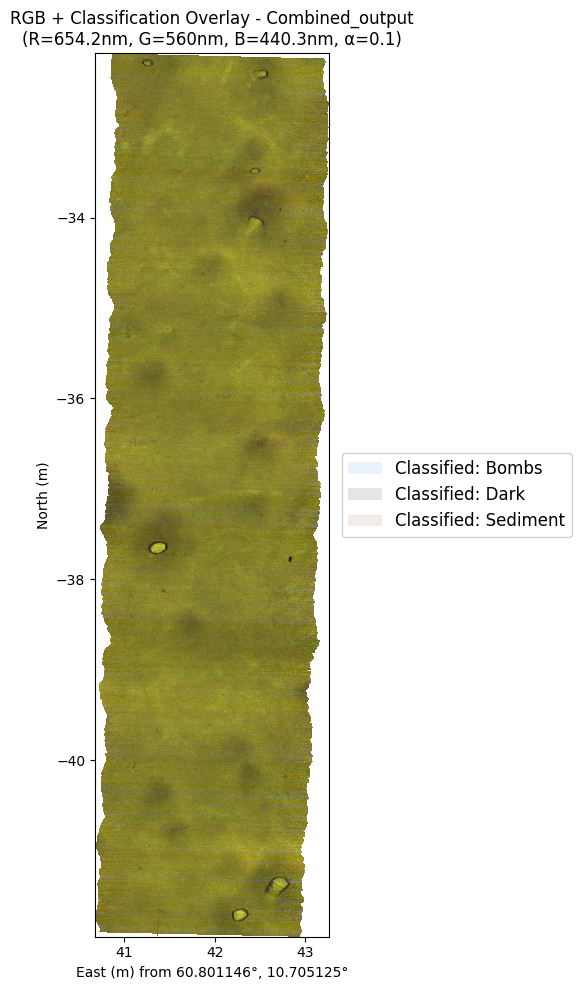

In [ ]:
# Plot RGB + classification overlay
cube.plot_classification_overlay(
    coordinate_system="NED",
    use_corrected=True,
    figsize=(40, 10),
    alpha=0.1,  # % transparency
    cmap="tab10",
    show_legend=True,
)

In [ ]:
# 🔍 TRACE SPECIFIC PIXELS THROUGH THE FILTERING PROCESS
import numpy as np

unfiltered_map = classification_results["classification_map"]
filtered_map = filtering_results["filtered_map"]

print("=" * 60)
print("🔍 CHECKING IF BOMBS ARE BEING CHANGED TO DARK")
print("=" * 60)

# Find bomb pixels in unfiltered map
bomb_pixels_unfiltered = np.where(unfiltered_map == "training_bombs")
n_bombs_unfiltered = len(bomb_pixels_unfiltered[0])

print(f"\nBombs in UNFILTERED: {n_bombs_unfiltered} pixels")

# Check what happened to those bomb pixels in filtered map
changed_to_dark = 0
changed_to_empty = 0
stayed_bomb = 0
changed_to_sediment = 0

for i in range(n_bombs_unfiltered):
    row, col = bomb_pixels_unfiltered[0][i], bomb_pixels_unfiltered[1][i]
    filtered_value = filtered_map[row, col]

    if filtered_value == "training_bombs":
        stayed_bomb += 1
    elif filtered_value == "training_dark":
        changed_to_dark += 1
    elif filtered_value == "":
        changed_to_empty += 1
    elif filtered_value == "training_sediment":
        changed_to_sediment += 1

print(f"\nWhat happened to the {n_bombs_unfiltered} bomb pixels after filtering?")
print(
    f"  ✅ Stayed as bombs: {stayed_bomb} pixels ({stayed_bomb/n_bombs_unfiltered*100:.1f}%)"
)
print(
    f"  🔄 Changed to DARK: {changed_to_dark} pixels ({changed_to_dark/n_bombs_unfiltered*100:.1f}%)"
)
print(
    f"  ❌ Changed to empty: {changed_to_empty} pixels ({changed_to_empty/n_bombs_unfiltered*100:.1f}%)"
)
print(
    f"  🔄 Changed to sediment: {changed_to_sediment} pixels ({changed_to_sediment/n_bombs_unfiltered*100:.1f}%)"
)

# Now check DARK pixels
print("\n" + "=" * 60)
print("🔍 CHECKING DARK PIXELS")
print("=" * 60)

dark_pixels_unfiltered = np.where(unfiltered_map == "training_dark")
n_dark_unfiltered = len(dark_pixels_unfiltered[0])

print(f"\nDark in UNFILTERED: {n_dark_unfiltered} pixels")

stayed_dark = np.sum(filtered_map == "training_dark")
print(f"Dark in FILTERED: {stayed_dark} pixels")
print(
    f"Removed: {n_dark_unfiltered - stayed_dark} pixels ({(n_dark_unfiltered - stayed_dark)/n_dark_unfiltered*100:.1f}%)"
)

# Sample some pixels that changed from bomb to dark
if changed_to_dark > 0:
    print("\n🔍 SAMPLE: Bomb pixels that became DARK:")
    sample_count = 0
    for i in range(n_bombs_unfiltered):
        if sample_count >= 10:
            break
        row, col = bomb_pixels_unfiltered[0][i], bomb_pixels_unfiltered[1][i]
        if filtered_map[row, col] == "training_dark":
            print(f"  Pixel [{row}, {col}]: bomb → dark")
            sample_count += 1

🔍 CHECKING IF BOMBS ARE BEING CHANGED TO DARK

Bombs in UNFILTERED: 1507 pixels

What happened to the 1507 bomb pixels after filtering?
  ✅ Stayed as bombs: 1415 pixels (93.9%)
  🔄 Changed to DARK: 0 pixels (0.0%)
  ❌ Changed to empty: 92 pixels (6.1%)
  🔄 Changed to sediment: 0 pixels (0.0%)

🔍 CHECKING DARK PIXELS

Dark in UNFILTERED: 86474 pixels
Dark in FILTERED: 83768 pixels
Removed: 2706 pixels (3.1%)


In [ ]:
# 🔍 CHECK IF REMOVED PIXELS BECAME SEDIMENT
print("\n" + "=" * 60)
print("🔍 VERIFYING SEDIMENT COUNT CHANGED")
print("=" * 60)

unfiltered_map = classification_results["classification_map"]
filtered_map = filtering_results["filtered_map"]

sediment_unfiltered = np.sum(unfiltered_map == "training_sediment")
sediment_filtered = np.sum(filtered_map == "training_sediment")

print(f"\nSediment in UNFILTERED: {sediment_unfiltered} pixels")
print(f"Sediment in FILTERED: {sediment_filtered} pixels")
print(f"Sediment GAINED: {sediment_filtered - sediment_unfiltered} pixels")

print(f"\nExpected gain: 92 (from bombs) + 2706 (from dark) = {92 + 2706} pixels")
print(f"Actual gain: {sediment_filtered - sediment_unfiltered} pixels")

# Check for empty strings
empty_count = np.sum(filtered_map == "")
print(f"\nEmpty strings in filtered_map: {empty_count} pixels")


🔍 VERIFYING SEDIMENT COUNT CHANGED

Sediment in UNFILTERED: 871307 pixels
Sediment in FILTERED: 871307 pixels
Sediment GAINED: 0 pixels

Expected gain: 92 (from bombs) + 2706 (from dark) = 2798 pixels
Actual gain: 0 pixels

Empty strings in filtered_map: 2798 pixels


In [ ]:
# 🔍 CHECK COLOR MAPPING
print("\n" + "=" * 60)
print("🔍 CHECKING COLOR MAPPING FOR PLOT")
print("=" * 60)

# Check what colors are assigned
if hasattr(cube, "roi_color_map"):
    print("\nROI Color Map:")
    for roi_name, color in cube.roi_color_map.items():
        print(f"  '{roi_name}': {color}")

# Check validation mapping
if hasattr(cube, "svm_validation_class_mapping"):
    print("\nValidation Class Mapping:")
    for val_roi, train_class in cube.svm_validation_class_mapping.items():
        print(f"  '{val_roi}' → '{train_class}'")

# Check what class names we're using
print(f"\nClass names in classification: {cube.svm_class_names}")


🔍 CHECKING COLOR MAPPING FOR PLOT

ROI Color Map:
  'dark spots': #000000
  'sediment': #8B4513
  'all bombs': #1E90FF
  'training_dark': yellow
  'training_sediment': cyan
  'training_bombs': magenta
  'dark#A': orange
  'dark#B': lime
  'dark#C': red
  'dark#D': blue
  'dark#E': orange
  'dark#F': lime
  'bomb#1': red
  'bomb#2': blue
  'sed#01': yellow
  'sed#02': cyan
  'sed#03': magenta
  'sed#04': orange
  'sed#05': lime
  'sed#06': red
  'sed#07': blue
  'sed#08': yellow
  'sed#09': cyan

Validation Class Mapping:
  'sediment' → 'training_sediment'
  'dark spots' → 'training_dark'
  'all bombs' → 'training_bombs'

Class names in classification: ['training_bombs', 'training_dark', 'training_sediment']


## 🔥 NEW WORKFLOW: Test Renamed Classes

**The new workflow:**
1. Classification → `classified_*` (bombs, dark, sediment)
2. Filtering → creates `filtered_*` for small clusters
3. Merge → `filtered_* + classified_sediment` → `new_sediment`
4. Validation → compare 3 classes against validation ROIs

In [ ]:
# STEP 1: Reload module to get new changes
import importlib

importlib.reload(georef)
print("✅ Module reloaded with new naming!")

In [ ]:
# STEP 2: Classify segment (should output classified_*)
print("🎯 STEP 2: CLASSIFICATION")
print("=" * 60)

classification_results_new = cube.classify_segment(
    segment_start=config.UHI_TRACK_RANGE_5[0],
    segment_end=config.UHI_TRACK_RANGE_5[1],
    use_corrected=True,
    quiet=False,
)

print(f"\n✅ Classification complete!")
print(f"   Classes: {classification_results_new['class_names']}")
print(f"\n📊 Pixel counts:")
for class_name in classification_results_new["class_names"]:
    count = np.sum(classification_results_new["classification_map"] == class_name)
    print(f"   {class_name}: {count} pixels")

In [ ]:
# STEP 3: Plot classification (3 classes: classified_bombs, classified_dark, classified_sediment)
print("📊 Plotting classification map (3 classes)...")

# Create temporary ROI collection from classification
classification_rois = {}
for class_name in classification_results_new["class_names"]:
    mask = classification_results_new["classification_map"] == class_name
    rows, cols = np.where(mask)
    # Convert to (slit, track) coordinates
    pixels = [(col, row + config.UHI_TRACK_RANGE_5[0]) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        classification_rois[class_name] = pixels

print(f"ROIs created: {list(classification_rois.keys())}")

# Plot with plot_georef
cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    figsize=(40, 10),
    roi_collection=classification_rois,
    roi_marker_size=1,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

In [ ]:
# STEP 4: Apply filtering (creates filtered_bombs and filtered_dark)
print("\n🧹 STEP 4: FILTERING")
print("=" * 60)

filtering_results_new = cube.filter_classification(
    classification_map=classification_results_new["classification_map"],
    class_names=classification_results_new["class_names"],
    filter_bombs=True,
    filter_dark=True,
    filter_sediment=False,
    min_area_px=10,
    connectivity=8,
    morph_close_radius=0,  # Disabled
    morph_open_radius=0,  # Disabled
    merge_proximity_px=0,
    quiet=False,
)

print(f"\n✅ Filtering complete!")
print(f"   All classes after filtering: {filtering_results_new['all_classes']}")

In [ ]:
# STEP 5: Plot filtered map (5 classes!)
print("📊 Plotting filtered map (5 classes: classified_* + filtered_*)...")

# Create ROI collection from filtered map
filtered_rois = {}
for class_name in filtering_results_new["all_classes"]:
    mask = filtering_results_new["filtered_map"] == class_name
    rows, cols = np.where(mask)
    pixels = [(col, row + config.UHI_TRACK_RANGE_5[0]) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        filtered_rois[class_name] = pixels

print(f"ROIs created: {list(filtered_rois.keys())}")
print(f"\n📊 Pixel counts:")
for class_name in sorted(filtered_rois.keys()):
    print(f"   {class_name}: {len(filtered_rois[class_name])} pixels")

# Plot with plot_georef
cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    figsize=(40, 10),
    roi_collection=filtered_rois,
    roi_marker_size=1,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

In [ ]:
# STEP 6: Merge filtered classes to create new_sediment
print("\n🔀 STEP 6: MERGE FILTERED CLASSES")
print("=" * 60)

merge_results = cube.merge_filtered_to_sediment(
    filtered_map=filtering_results_new["filtered_map"],
    quiet=False,
)

print(f"\n✅ Merge complete!")
print(f"   Final classes for validation: {merge_results['class_names']}")

In [ ]:
# STEP 7: Plot validation map (3 classes: classified_bombs, classified_dark, new_sediment)
print("📊 Plotting validation map (3 classes)...")

# Create ROI collection from validation map
validation_map_rois = {}
for class_name in merge_results["class_names"]:
    mask = merge_results["validation_map"] == class_name
    rows, cols = np.where(mask)
    pixels = [(col, row + config.UHI_TRACK_RANGE_5[0]) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        validation_map_rois[class_name] = pixels

print(f"ROIs created: {list(validation_map_rois.keys())}")
print(f"\n📊 Pixel counts:")
for class_name in sorted(validation_map_rois.keys()):
    print(f"   {class_name}: {len(validation_map_rois[class_name])} pixels")

# Plot with plot_georef
cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    figsize=(40, 10),
    roi_collection=validation_map_rois,
    roi_marker_size=1,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

In [ ]:
# STEP 8: Validate using the 3-class map
print("\n📊 STEP 8: VALIDATION")
print("=" * 60)

validation_results_final = cube.validate_classification(
    classification_map=merge_results["validation_map"],
    segment_start=config.UHI_TRACK_RANGE_5[0],
    segment_end=config.UHI_TRACK_RANGE_5[1],
    validation_rois=validation_rois,
    validation_class_mapping={
        "sediment": "new_sediment",
        "dark spots": "classified_dark",
        "all bombs": "classified_bombs",
    },
    quiet=False,
)

# Print summary
if validation_results_final:
    print(f"\n" + "=" * 60)
    print(f"📊 VALIDATION RESULTS (NEW WORKFLOW)")
    print(f"=" * 60)
    print(f"Overall Accuracy: {validation_results_final['accuracy']:.3f}")

    print(f"\n📋 Per-Class Results:")
    for class_name in merge_results["class_names"]:
        print(f"\n{class_name}:")
        print(
            f"  Precision: {validation_results_final['precision_per_class'][class_name]:.3f}"
        )
        print(
            f"  Recall:    {validation_results_final['recall_per_class'][class_name]:.3f}"
        )
        print(
            f"  F1 Score:  {validation_results_final['f1_per_class'][class_name]:.3f}"
        )
        print(
            f"  Support:   {validation_results_final['support_per_class'][class_name]} pixels"
        )

## ✅ Summary of New Workflow

**Complete workflow implemented:**

1. **Classification** → `classified_bombs`, `classified_dark`, `classified_sediment` (3 classes)
2. **Filtering** → Creates `filtered_bombs`, `filtered_dark` for small clusters (5 classes total)
3. **Merge** → `classified_sediment + filtered_* → new_sediment` (3 classes for validation)
4. **Validation** → Compare against validation ROIs

**Key improvements:**
- ✅ Clear naming: `training_*` (for training) vs `classified_*` (predictions) vs `filtered_*` (removed pixels)
- ✅ No empty strings - all pixels have a class
- ✅ Can plot 5-class map to see what was filtered
- ✅ Can validate against 3-class map
- ✅ Morphological operations properly disabled (radius=0)